
# PRÁCTICA: Comparación KNN vs Regresión Logística vs SVM  
## Dataset: Breast Cancer Wisconsin

**Instrucciones**
- Puedes desarrollar tu código en las celdas que se faciliten. En algunos casos, hay alguna ayuda.
- Si prefieres otra forma de desarrollo también es válida. Completa el trahajo con tus propios comentarios


---
## 0️⃣ Imports y configuración

In [16]:

# Importa lo necesario para:
# - pandas, numpy
# - train_test_split
# - StandardScaler
# - SimpleImputer (si hay NaN)
# - KNeighborsClassifier
# - LogisticRegression
# - SVC
# - métricas: accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
# - matplotlib.pyplot

# Escribe aquí tus imports

# Datos y preprocesamiento
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Modelos de Clasificación
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Modelos de Regresión
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas de Clasificación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Métricas de Regresión
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Todas las librerías importadas correctamente")


✅ Todas las librerías importadas correctamente


---
## 1️⃣ Carga y exploración del dataset

In [17]:

# Carga el CSV (ajusta el nombre si es necesario)
df_cancer = pd.read_csv('breat_cancer_wisconsin_dataset.csv')

# Muestra shape y primeras filas
print(df_cancer.shape)
print(df_cancer.head())
print(df_cancer.info())

# Identifica la columna objetivo (normalmente 'diagnosis')
print("la columna objetivo es: diagnosis")

# Comprueba valores
print("datos de la columna diagnosis: ", df_cancer['diagnosis'].unique())

# Comprueba balanceo de clases
print("balanceo de clases en diagnosis: ", df_cancer['diagnosis'].value_counts())


(569, 33)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  


**Pregunta (responder en una frase):**  
- ¿El dataset está balanceado? Como he enseñado arriba, el dataset está algo desbalanceado, hay casi 1.7 mas de tumores benignos que malignos.
- ¿Hay NaN? Si los hay, ¿qué estrategia usarás (drop vs imputación) y por qué? Si hay Nan, los del campo Unnamed: 32, que tiene todos los valores nulos, porque en el final del csv hay una coma extra al final que produce un error, haciendo que se añada esta columna sin valores.


---
## 2️⃣ Limpieza mínima + definición de X e y

In [18]:

# Elimina columnas irrelevantes si existen (típicas: 'id', 'Unnamed: 32', 'Unnamed: 0')
df_cancer.drop(columns=['id', 'Unnamed: 32'], inplace=True)

# Define X e y
X = df_cancer.drop(columns=['diagnosis'])
y = df_cancer['diagnosis'].to_frame()

# Verifica shapes
print("Shape de X: ", X.shape)
print("Shape de y: ", y.shape)


Shape de X:  (569, 30)
Shape de y:  (569, 1)


---
## 3️⃣ Train/Test split

In [19]:

# Divide en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verifica el resultado
print("Shape de X_train: ", X_train.shape)
print("Shape de X_test: ", X_test.shape)
print("Shape de y_train: ", y_train.shape)
print("Shape de y_test: ", y_test.shape)


Shape de X_train:  (455, 30)
Shape de X_test:  (114, 30)
Shape de y_train:  (455, 1)
Shape de y_test:  (114, 1)


---
## 4️⃣ Tratamiento de NaN + Escalado (obligatorio para KNN y SVM)

In [20]:

# Decisiones a tomar si hay NaN

# Si NO hay NaN

# Escala con StandardScaler (fit en train, transform en test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verifica que no quedan NaN
print("NaN en X_train_scaled: ", np.isnan(X_train_scaled).sum())
print("NaN en X_test_scaled: ", np.isnan(X_test_scaled).sum())

NaN en X_train_scaled:  0
NaN en X_test_scaled:  0



**Pregunta**  
¿Por qué es obligatorio escalar en KNN y SVM?
Porque al tratarse de puntos en un espacio determinado, si ponemos unos datos muy grandes, haría que las rectas, lineas o puntos que buscamos tengan también dimensiones enormes, afectando negativamente a la precisión del modelo


---
## 5️⃣ Modelo 1: KNN (búsqueda de k)

In [21]:

# Recorre k impares (puedes consultar la teoría)
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
# Calcula y guarda:
# - accuracy (en test)
# - AUC (en test) usando predict_proba
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy (KNN): ", accuracy)
print("AUC (KNN): ", auc)
print("Clasification report: ", classification_report(y_test, y_pred))
confusion_matrix_result = confusion_matrix(y_test, y_pred)
print("Confusion Matrix: \n", confusion_matrix_result)
# Identifica el mejor k según accuracy y el mejor k según AUC: segun accuracy entre 3,5,7 es indiferente pero en AUC el mejor es 5


Accuracy (KNN):  0.9473684210526315
AUC (KNN):  0.9819849328529314
Clasification report:                precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix: 
 [[68  3]
 [ 3 40]]


---
## 6️⃣ Gráfica: superponer Accuracy y AUC vs k

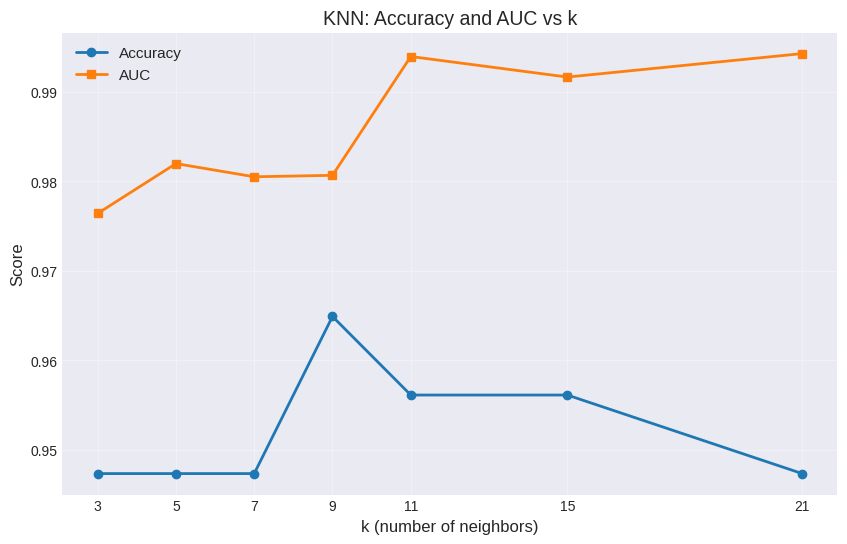

Best k by Accuracy: 9 (score: 0.9649)
Best k by AUC: 21 (score: 0.9943)


In [22]:
# Test different k values (odd numbers)
k_values = [3, 5, 7, 9, 11, 15, 21]
accuracies = []
aucs = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)
    
    y_pred_k = knn_model.predict(X_test_scaled)
    y_pred_proba_k = knn_model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred_k)
    auc_score = roc_auc_score(y_test, y_pred_proba_k)
    
    accuracies.append(acc)
    aucs.append(auc_score)

# Plot Accuracy and AUC vs k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', label='Accuracy', linewidth=2)
plt.plot(k_values, aucs, marker='s', label='AUC', linewidth=2)
plt.xlabel('k (number of neighbors)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('KNN: Accuracy and AUC vs k', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

# Print best k values
best_k_accuracy = k_values[accuracies.index(max(accuracies))]
best_k_auc = k_values[aucs.index(max(aucs))]
print(f"Best k by Accuracy: {best_k_accuracy} (score: {max(accuracies):.4f})")
print(f"Best k by AUC: {best_k_auc} (score: {max(aucs):.4f})")


**Pregunta**  
¿Coincide el mejor k según Accuracy con el mejor k según AUC? ¿Por qué podría no coincidir?


---
## 7️⃣ Entrena el KNN final (elige un k) + métricas

In [23]:

# Elige k final (puede ser best_k_auc o un criterio razonado)



# Entrena y evalúa:
# - accuracy
# - matriz de confusión
# - classification_report
# - curva ROC + AUC

---
## 8️⃣ Modelo 2: Regresión Logística

In [24]:

# Entrena LogisticRegression (max_iter suficiente)
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1200)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]



# Evalúa:
# - accuracy
# - matriz de confusión
# - AUC
# - curva ROC
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)
print("Accuracy (Logistic Regression): ", accuracy_logreg)
print("Confusion Matrix (Logistic Regression): \n", conf_matrix_logreg)
print("AUC (Logistic Regression): ", auc_logreg)

Accuracy (Logistic Regression):  0.9736842105263158
Confusion Matrix (Logistic Regression): 
 [[70  1]
 [ 2 41]]
AUC (Logistic Regression):  0.99737962659679


---
## 9️⃣ Modelo 3: SVM

In [25]:

# Entrena SVM razonadamente
# --- ENTRENAR SVM LINEAL ---
svm_linear = LinearSVC(
    C=0.01,
    max_iter=1000
)

svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

print("🔵 SVM LINEAL - RESULTADOS:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_linear):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))
print("Classification Report:\n", classification_report(y_test, y_pred_linear))

# Evalúa (accuracy + AUC + ROC)

🔵 SVM LINEAL - RESULTADOS:
Accuracy: 0.9825
Confusion Matrix:
 [[71  0]
 [ 2 41]]
Classification Report:
               precision    recall  f1-score   support

           B       0.97      1.00      0.99        71
           M       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [26]:
# --- ENTRENAR SVM RBF ---
svm_rbf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='auto',
    probability=True
)

svm_rbf.fit(X_train_scaled, y_train)

# --- PREDECIR ---
y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_pred_proba_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

# --- EVALUAR ---
print("SVM RBF - RESULTADOS:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("Classification Report:\n", classification_report(y_test, y_pred_rbf))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_rbf):.4f}")

SVM RBF - RESULTADOS:
Accuracy: 0.9825
Confusion Matrix:
 [[71  0]
 [ 2 41]]
Classification Report:
               precision    recall  f1-score   support

           B       0.97      1.00      0.99        71
           M       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC: 0.9974


In [27]:
# --- ENTRENAR SVM POLY ---
svm_poly = SVC(
    kernel='rbf',
    C=1.0,
    gamma='auto',
)

svm_poly.fit(X_train_scaled, y_train)

# --- PREDECIR ---
y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_pred_proba_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

# --- EVALUAR ---
print("SVM RBF - RESULTADOS:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("Classification Report:\n", classification_report(y_test, y_pred_rbf))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_rbf):.4f}")

SVM RBF - RESULTADOS:
Accuracy: 0.9825
Confusion Matrix:
 [[71  0]
 [ 2 41]]
Classification Report:
               precision    recall  f1-score   support

           B       0.97      1.00      0.99        71
           M       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC: 0.9974


---
## 🔟 Comparación final: ROC superpuestas + tabla

In [28]:

# Dibuja en el MISMO gráfico las ROC de:
# - KNN final
# - Regresión logística
# - SVM (elige la mejor versión: lineal o RBF)


# Puedes crear una tabla comparativa
# Test different k values (odd numbers)


---
## 1️⃣1️⃣ Conclusiones

Responde razonadamente:

1. ¿Qué modelo elegirías para este problema y por qué? Los modelos que mas accuracy me dan son los 3 de SVM, me dan los 3 el mismo resultado, 0,9825 ante el 0,97 de la regresión logistica y el 0,94 del knn, por lo que seleccionaría por el momento el modelo mas simple, que es el svm lineal, mientras este sea el volumen de datos, seguramente cuando haya mas datos, las cosas cambiarían probablemente

La regresión logistica es bastante valorable porque nos da una probabilidad que nos interesa en este caso médico y el AUC nos ayuda bastante en este caso.

2. ¿Qué métrica te parece más relevante en un contexto médico: accuracy o AUC? Justifica tu respuesta. Para mi gusto, creo que el AUC tiene una mejor capacidad, porque además de los aciertos que nos puede dar el accuracy, a no ser que sea un 100%, nos interesa también tomar en cuenta los falsos positivos y los falsos negativos, para saber que medidas tomar en cada caso y se adapta mejor a estos casos medicos al ser una selección binaria.

El accuracy en caso de estar balanceado es bastante mejor, ya que si está desbalanceado, el accuracy se puede ver afectado por el tipo de datos.

3. Si el dataset fuera 100 veces más grande, ¿cuál de los tres modelos crees que sería menos recomendable y por qué? Seguramente el modelo más óptimo sería el SVM, ya que podriamos ajustarlo bastante mejor a los datos, ya que los otros modelos en dataset mas grandes, pierden bastante eficacia mientras que el SVM se puede adaptar y clasificar los datos cambiando distintos parametros.

El knn sería el menos recomendable, porque funciona bien cuando el dataset es pequeño, a la hora de calcular distancias es bastante potencia.

4. ¿Cuál es el modelo más interpretable de los tres? A la hora de clasificar e interpretar este tipo de datos, el modelo de regresión logistica nos puede ayudar bastante mas a interpretar los datos ya que al ser un caso con 2 opciones, nos ayuda a clasificar las diferentes posibilidades y tener información de interés como los falsos positivos.
